In [1]:
# Import Libraries

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# Load Dataset

df = pd.read_csv("bike_sharing_day.csv")

print(df.head)

<bound method NDFrame.head of      instant      dteday  season  yr  mnth  holiday  weekday  workingday  \
0          1  2011-01-01       1   0     1        0        6           0   
1          2  2011-01-02       1   0     1        0        0           0   
2          3  2011-01-03       1   0     1        0        1           1   
3          4  2011-01-04       1   0     1        0        2           1   
4          5  2011-01-05       1   0     1        0        3           1   
..       ...         ...     ...  ..   ...      ...      ...         ...   
726      727  2012-12-27       1   1    12        0        4           1   
727      728  2012-12-28       1   1    12        0        5           1   
728      729  2012-12-29       1   1    12        0        6           0   
729      730  2012-12-30       1   1    12        0        0           0   
730      731  2012-12-31       1   1    12        0        1           1   

     weathersit      temp     atemp       hum  windspeed 

In [3]:
# Select imp features 

selected_features = ["temp", "hum", "windspeed", "workingday", "season"]

df_small = df[selected_features + ["cnt"]]

df_small.head()

,temp,hum,windspeed,workingday,season,cnt
0,0.344167,0.805833,0.160446,0,1,985
1,0.363478,0.696087,0.248539,0,1,801
2,0.196364,0.437273,0.248309,1,1,1349
3,0.200000,0.590435,0.160296,1,1,1562
4,0.226957,0.436957,0.186900,1,1,1600


In [4]:
# Target Values

X = df_small[["temp", "hum", "windspeed", "workingday","season" ]]

y = df_small["cnt"]

In [5]:
# Train-Test split

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y,
    test_size=0.2,
    random_state=42
)

In [6]:
# Add constant for intercept

X_train_lm = sm.add_constant(X_train)
X_test_lm = sm.add_constant(X_test)

In [ ]:
# GLM Model - Poisson

glm_model = sm.GLM(
    y_train,
    X_train_lm,
    family=sm.families.Poisson()
)

glm_results = glm_model.fit()

print(glm_results.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                    cnt   No. Observations:                  584
Model:                            GLM   Df Residuals:                      578
Model Family:                 Poisson   Df Model:                            5
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.4146e+05
Date:                Sat, 07 Mar 2026   Deviance:                   2.7701e+05
Time:                        21:19:20   Pearson chi2:                 2.67e+05
No. Iterations:                     5   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          8.0390      0.004   1830.741      0.0

In [8]:
# GLM Model - Gaussian

glm_model_g = sm.GLM(
    y_train,
    X_train_lm,
    family=sm.families.Gaussian()
)
glm_results_g = glm_model_g.fit()

print(glm_results_g.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:                    cnt   No. Observations:                  584
Model:                            GLM   Df Residuals:                      578
Model Family:                Gaussian   Df Model:                            5
Link Function:               Identity   Scale:                      1.8571e+06
Method:                          IRLS   Log-Likelihood:                -5040.5
Date:                Sat, 07 Mar 2026   Deviance:                   1.0734e+09
Time:                        21:19:20   Pearson chi2:                 1.07e+09
No. Iterations:                     3   Pseudo R-squ. (CS):             0.6263
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       3332.0421    375.696      8.869      0.0

In [9]:
# Prediction
y_pred = glm_results.predict(X_test_lm)
y_pred_g = glm_results_g.predict(X_test_lm)

In [10]:
# Metrics

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print("Possion:\n")
print("RMSE:", rmse)
print("R2 Score:", r2)
print("")

mse_g = mean_squared_error(y_test, y_pred_g)
rmse_g = np.sqrt(mse_g)
r2_g = r2_score(y_test, y_pred_g)
print("Gaussian:\n")
print("RMSE:", rmse_g)
print("R2 Score:", r2_g)

Possion:

RMSE: 1433.8285748946892
R2 Score: 0.48730056539619904

Gaussian:

RMSE: 1364.2520187131465
R2 Score: 0.5358508213914726


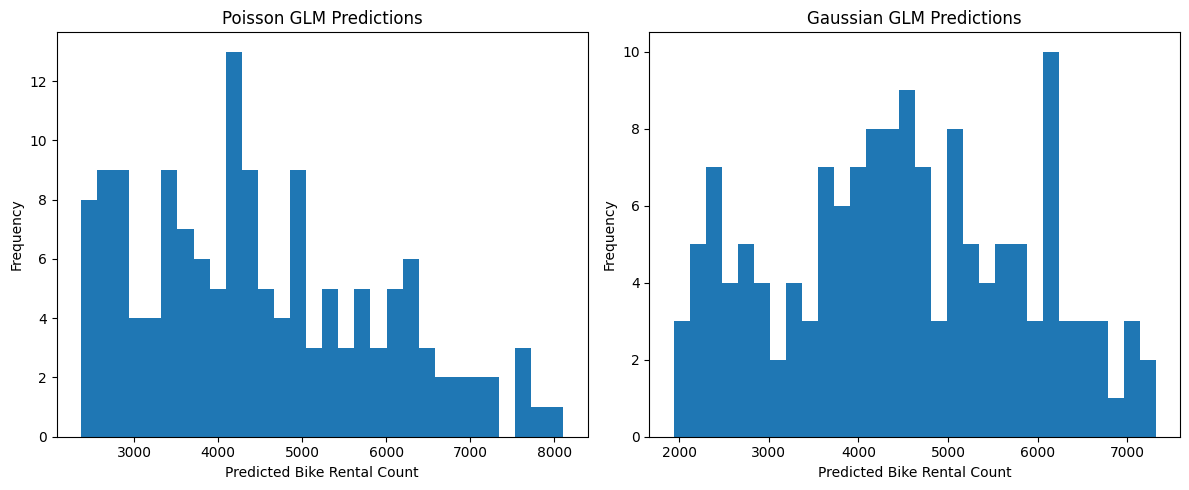

In [11]:
# Visualization

fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Poisson
axes[0].hist(y_pred, bins=30)
axes[0].set_xlabel("Predicted Bike Rental Count")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Poisson GLM Predictions")

# Gaussian
axes[1].hist(y_pred_g, bins=30)
axes[1].set_xlabel("Predicted Bike Rental Count")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Gaussian GLM Predictions")

plt.tight_layout()
plt.show()